# EEP 564 (TinyML) - Lab 7 - Part II: Tiny Ensemble Learning

## Overview

In this part of Lab 7, you will explore **ensemble learning** within a TinyML context. The focus is on building pipelines that combine multiple models and compress them for deployment on edge devices like the Arduino Nano 33 BLE Sense.

### Key Concepts

This notebook demonstrates:
- **Multiple representations**: Training separate autoencoders on different scaled versions of the same IMU dataset (raw, standard-scaled, and min-max scaled)
- **Feature extraction**: Using encoders to create latent representations of sensor data
- **Hierarchical classification**: Training individual classifiers on latent features
- **Ensemble methods**: Stacking multiple classifier outputs to create a meta-classifier
- **Model compression**: Applying pruning and quantization-aware training (QAT) for deployment
- **TinyML deployment**: Converting models to C arrays for Arduino

### Dataset Note

This lab uses the **mHealth dataset** (specifically `mHealth_subject6.log`), which is the **same dataset used in Lab 6**. We extract the 6 IMU sensor features: accelerometer X/Y/Z and gyroscope X/Y/Z.

### Objectives

- Understand how multiple models can be combined and evaluated using ensemble techniques
- Explore the challenges and methods involved in compressing and deploying these models on resource-constrained hardware
- Critically assess the behavior of the deployed models using both live and recorded IMU data
- Learn the impact of different feature scaling approaches on model performance

---

## 📘 Discussion Questions: Understanding the Deployment Pipeline

Please answer the following questions based on the full end-to-end pipeline you've implemented in this notebook. Provide **brief but complete answers** to each sub-part.

---

### 🔧 1. Model Architecture and Flow Diagram

- Draw an **overall diagram** showing how the different models (encoder, classifier, stacked meta-classifier) are connected.
  - You can use an online tool like https://alexlenail.me/NN-SVG/ to do this step.
  - You can put additional texts under your figure in your PDF submission.
- Include the following in your diagram:
  - **Input data shape** to each model and meaning of inputs
  - Explain what the input data represents (e.g., type of inputs, how the data is prepared).
  - **Latent dimension sizes**
  - **Number of neurons** in each Dense layer of each model
  - Output softmax vector size

---

### 🧠 2. Pruning and QAT Methodology

- How does this code implement pruning and quantization-aware training (QAT)?
- Is it a **simple two-step pruning + QAT** pipeline or does it include **additional techniques**?
- If additional techniques are required:
  - What extra steps are involved?
  - Why are these extra steps necessary?
  - How do they improve deployment on resource-constrained devices?

---

### 🧪 3. Real-World Deployment on Arduino BLE

- **Deploy the quantized model** using the provided `Tiny_Ensemble_Learning.ino` sketch.
- Place your Arduino Nano 33 BLE Sense **flat on a surface** and open the serial monitor.
- **Take a screenshot** of the serial output.
- Is the output **acceptable and accurate**? If not:
  - What issues do you observe?

---

### 📥 4. Testing with Recorded IMU Data

- Use `Raw_IMU_Recorder.ino` to collect new sensor data (minimum **500 rows**).
- Include only the 6 features: `acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z`. **You may need to copy paste raw data from serial monitor output to a csv file**
- Save as `imu_500_rows.csv` and upload to Colab.
- Run the **last part of this notebook** to classify it using all three models and the stacked classifier.
- Are the predictions **reasonable for the resting BLE condition**?  What issues do you observe?

---

### ❗️ 5. Diagnosing Unexpected Results

If you notice **unexpected or unstable results** in parts (3) and (4):

- What might be the root causes?
  - Consider sensor noise, scaling mismatch, quantization errors, model bias, or data representation
- What are **possible fixes**?

---

## 📦 Section 1: Installation and Setup

Install required libraries for TensorFlow, model optimization, and data processing:

In [4]:
# Install Tensorflow and Tensorflow model optimization
%pip install "tensorflow<2.21" tensorflow-model-optimization
# Install other required packages
%pip install numpy scipy scikit-learn pandas matplotlib umap-learn seaborn

We then apply the workaround for Tensorflow Lite and Tensorflow Model Optimization:

In [5]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["KERAS_BACKEND"] = "tensorflow"

## 🧩 Section 2: Data Loading and Preprocessing

Load the mHealth dataset (same as Lab 6) with 6 IMU features and 12 activity labels.

In [6]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("mHealth_subject6.log", sep='\t', header=None)

# Exclude unlabeled (label=0) entries
df = df[df[23] > 0]

# Rename sensor columns
sensor_cols = {5: 'Accel_X', 6: 'Accel_Y', 7: 'Accel_Z',
               8: 'Gyro_X', 9: 'Gyro_Y', 10: 'Gyro_Z'}
df.rename(columns=sensor_cols, inplace=True)

# Extract features and label
sensor_df = df[list(sensor_cols.values())].copy()  # Avoid SettingWithCopyWarning
labels = df[23].values - 1  # Convert to 0-based labels (0 to 11)
sensor_df['Label'] = labels

# Print stats for original features
print("Original Sensor Statistics (Features only):")
print(sensor_df.iloc[:, :-1].describe())

Original Sensor Statistics (Features only):
            Accel_X       Accel_Y       Accel_Z        Gyro_X        Gyro_Y  \
count  32205.000000  32205.000000  32205.000000  32205.000000  32205.000000   
mean       3.268805     -9.153526      0.700608     -0.020571     -0.520382   
std        4.253270      5.397648      6.433731      0.325434      0.571107   
min      -22.091000    -19.571000    -19.363000     -0.977740     -1.611600   
25%        1.284000    -10.420000     -1.359900     -0.235620     -0.863040   
50%        2.427500     -9.583100      1.509900     -0.027829     -0.731710   
75%        4.725200     -8.039700      2.456600      0.192950     -0.452160   
max       20.003000     20.909000     24.599000      1.463800      1.557200   

             Gyro_Z  
count  32205.000000  
mean      -0.299817  
std        0.542112  
min       -1.206300  
25%       -0.662080  
50%       -0.479370  
75%        0.341850  
max        1.326100  


## 📊 Section 3: Feature Scaling for Ensemble Diversity

Create three scaled versions of the dataset (raw, standard-scaled, min-max) to train diverse models. Each scaling approach captures different data characteristics, which the ensemble meta-classifier will learn to combine optimally.

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Dictionary to store scalers and scaled dataframes
scalers = {}
scaled_dfs = {}

# Standard Scaler
scalers['std'] = StandardScaler()
sensor_std_scaled = scalers['std'].fit_transform(sensor_df)
scaled_dfs['std'] = pd.DataFrame(sensor_std_scaled, columns=sensor_df.columns)
scaled_dfs['std']['Label'] = labels

# Min-Max Scaler
scalers['minmax'] = MinMaxScaler()
sensor_minmax_scaled = scalers['minmax'].fit_transform(sensor_df)
scaled_dfs['minmax'] = pd.DataFrame(sensor_minmax_scaled, columns=sensor_df.columns)
scaled_dfs['minmax']['Label'] = labels

# Store raw (unscaled) dataframe for consistency
scaled_dfs['raw'] = sensor_df.copy()

# Print statistics for all scaling approaches
print("\nStandard Scaled Sensor Statistics (Features only):")
print(scaled_dfs['std'].iloc[:, :-1].describe())

print("\nMin-Max Scaled Sensor Statistics (Features only):")
print(scaled_dfs['minmax'].iloc[:, :-1].describe())


Standard Scaled Sensor Statistics (Features only):
            Accel_X       Accel_Y       Accel_Z        Gyro_X        Gyro_Y  \
count  3.220500e+04  3.220500e+04  3.220500e+04  3.220500e+04  3.220500e+04   
mean   2.824079e-17 -7.060198e-17  4.236119e-17  5.648158e-17 -1.023729e-16   
std    1.000016e+00  1.000016e+00  1.000016e+00  1.000016e+00  1.000016e+00   
min   -5.962518e+00 -1.930032e+00 -3.118551e+00 -2.941250e+00 -1.910735e+00   
25%   -4.666612e-01 -2.346381e-01 -3.202714e-01 -6.608157e-01 -5.999975e-01   
50%   -1.978050e-01 -7.958667e-02  1.257909e-01 -2.230210e-02 -3.700371e-01   
75%    3.424229e-01  2.063571e-01  2.729395e-01  6.561219e-01  1.194581e-01   
max    3.934491e+00  5.569646e+00  3.714604e+00  4.561272e+00  3.637870e+00   

             Gyro_Z  
count  3.220500e+04  
mean  -5.648158e-17  
std    1.000016e+00  
min   -1.672159e+00  
25%   -6.682549e-01  
50%   -3.312160e-01  
75%    1.183661e+00  
max    2.999273e+00  

Min-Max Scaled Sensor Statistics (Fea

## 🔀 Section 4: Windowing and Train-Test Split

Slice 100-timestep windows over each activity class, using 70/30 temporal split for train/test to maintain temporal consistency across the three scaled datasets.

In [8]:
# ------------------- Windowing Function -------------------
WINDOW_SIZE = 100
STRIDE = 1

def create_windows(X_seq, label):
    windows = []
    labels = []
    for i in range(0, len(X_seq) - WINDOW_SIZE + 1, STRIDE):
        window = X_seq[i:i+WINDOW_SIZE].flatten()
        windows.append(window)
        labels.append(label)
    return windows, labels

def window_and_split(df_scaled):
    X_train_windows, X_test_windows = [], []
    y_train_labels, y_test_labels = [], []

    for label in sorted(df_scaled['Label'].unique()):
        df_class = df_scaled[df_scaled['Label'] == label]
        X_class = df_class.iloc[:, :-1].values
        split_idx = int(0.7 * len(X_class))
        X_train_seq = X_class[:split_idx]
        X_test_seq = X_class[split_idx:]

        train_windows, train_labels = create_windows(X_train_seq, label)
        test_windows, test_labels = create_windows(X_test_seq, label)

        X_train_windows.extend(train_windows)
        y_train_labels.extend(train_labels)
        X_test_windows.extend(test_windows)
        y_test_labels.extend(test_labels)

    return (np.array(X_train_windows), np.array(X_test_windows),
            np.array(y_train_labels), np.array(y_test_labels))

# ------------------- Process all scaled datasets -------------------
datasets = {}
for scale_type in ['raw', 'std', 'minmax']:
    X_train, X_test, y_train, y_test = window_and_split(scaled_dfs[scale_type])
    datasets[scale_type] = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test
    }

# ------------------- Sanity Checks -------------------
for scale_type in ['raw', 'std', 'minmax']:
    print(f"\n{scale_type.upper()} Dataset:")
    print(f"  X_train shape: {datasets[scale_type]['X_train'].shape}")
    print(f"  X_test shape:  {datasets[scale_type]['X_test'].shape}")
    print(f"  y_train shape: {datasets[scale_type]['y_train'].shape}")
    print(f"  y_test shape:  {datasets[scale_type]['y_test'].shape}")


RAW Dataset:
  X_train shape: (21350, 600)
  X_test shape:  (8479, 600)
  y_train shape: (21350,)
  y_test shape:  (8479,)

STD Dataset:
  X_train shape: (21350, 600)
  X_test shape:  (8479, 600)
  y_train shape: (21350,)
  y_test shape:  (8479,)

MINMAX Dataset:
  X_train shape: (21350, 600)
  X_test shape:  (8479, 600)
  y_train shape: (21350,)
  y_test shape:  (8479,)


## 🎨 Section 5: Exploratory Data Analysis - t-SNE Visualization

Visualize the three scaled datasets in 2D to compare data separability and observe how scaling impacts activity clustering.

/tmp/ipykernel_5320/3356322290.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20')
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_5320/3356322290.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20')
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_5320/3356322290.py:15: MatplotlibDeprecationW

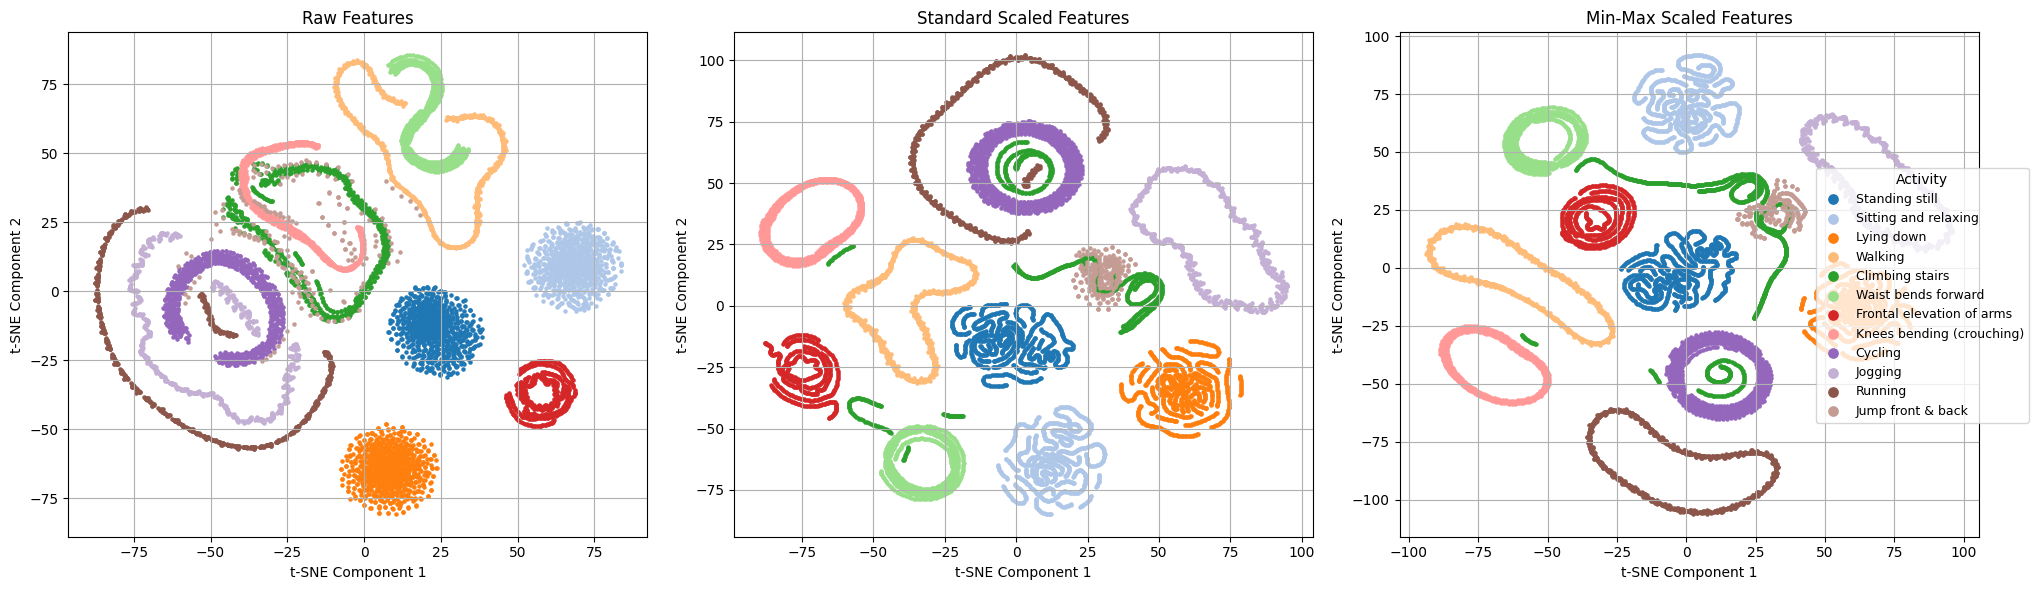

In [9]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap

# Assign activity label names and colors
label_map = {
    0: "Standing still", 1: "Sitting and relaxing", 2: "Lying down", 3: "Walking",
    4: "Climbing stairs", 5: "Waist bends forward", 6: "Frontal elevation of arms",
    7: "Knees bending (crouching)", 8: "Cycling", 9: "Jogging", 10: "Running", 11: "Jump front & back"
}

def run_tsne_and_plot(X_test, y_test, title, ax):
    unique_labels = sorted(np.unique(y_test))
    cmap = get_cmap('tab20')
    colors = {label: cmap(i % 20) for i, label in enumerate(unique_labels)}

    # t-SNE
    X_tsne = TSNE(n_components=2, perplexity=30, learning_rate=300, n_iter=1000, random_state=42).fit_transform(X_test)

    # Plot
    for label in unique_labels:
        idx = y_test == label
        ax.scatter(X_tsne[idx, 0], X_tsne[idx, 1], s=5, color=colors[label], label=label_map[label])
    ax.set_title(title)
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.grid(True)

# Plot all 3 side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, scale_type in enumerate(['raw', 'std', 'minmax']):
    title_map = {'raw': 'Raw Features', 'std': 'Standard Scaled Features', 'minmax': 'Min-Max Scaled Features'}
    run_tsne_and_plot(datasets[scale_type]['X_test'], datasets[scale_type]['y_test'],
                      title_map[scale_type], axes[idx])

# Add shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Activity", loc='center right', bbox_to_anchor=(1.02, 0.5), fontsize=9, markerscale=3)
plt.tight_layout()
plt.show()

## 🧠 Section 6: Autoencoders and Feature Extraction

Train three autoencoders (one per scaled version) to compress 600-dim windowed data to 32-dim latent representations. Each learns complementary features for ensemble diversity.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def build_encoder_decoder(input_dim, latent_dim=32):
    """Build and return both autoencoder and encoder models using Sequential API."""
    # Encoder model: input -> 64 -> latent
    encoder = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(latent_dim, activation='linear')
    ], name="encoder")
    encoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    # Full autoencoder: input -> 64 -> latent -> 64 -> output
    autoencoder = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(latent_dim, activation='linear'),
        Dense(64, activation='relu'),
        Dense(input_dim, activation='linear')
    ], name="autoencoder")
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    return autoencoder, encoder

# Train autoencoders for all three scaling approaches
models = {}
encoders = {}

for scale_type in ['raw', 'std', 'minmax']:
    print(f"\n{'='*50}")
    print(f"Training Autoencoder for {scale_type.upper()} features")
    print('='*50)

    X_train = datasets[scale_type]['X_train']
    input_dim = X_train.shape[1]

    autoencoder, encoder = build_encoder_decoder(input_dim)
    autoencoder.fit(X_train, X_train, epochs=50, batch_size=256, shuffle=True, verbose=1)

    models[scale_type] = autoencoder
    encoders[scale_type] = encoder

print("\n✅ All autoencoders trained successfully")


Training Autoencoder for RAW features
Epoch 1/50
84/84 [==============================] - 6s 7ms/step - loss: 14.2113
Epoch 2/50
84/84 [==============================] - 1s 9ms/step - loss: 8.3080
Epoch 3/50
84/84 [==============================] - 1s 9ms/step - loss: 7.4775
Epoch 4/50
84/84 [==============================] - 1s 8ms/step - loss: 6.7932
Epoch 5/50
84/84 [==============================] - 1s 8ms/step - loss: 6.3146
Epoch 6/50
84/84 [==============================] - 1s 10ms/step - loss: 5.9976
Epoch 7/50
84/84 [==============================] - 1s 8ms/step - loss: 5.7704
Epoch 8/50
84/84 [==============================] - 1s 12ms/step - loss: 5.5894
Epoch 9/50
84/84 [==============================] - 1s 13ms/step - loss: 5.4407
Epoch 10/50
84/84 [==============================] - 2s 19ms/step - loss: 5.3134
Epoch 11/50
84/84 [==============================] - 1s 13ms/step - loss: 5.2021
Epoch 12/50
84/84 [==============================] - 1s 9ms/step - loss: 5.1139
Epoc

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_5320/1325622446.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20')
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_5320/1325622446.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20')
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_

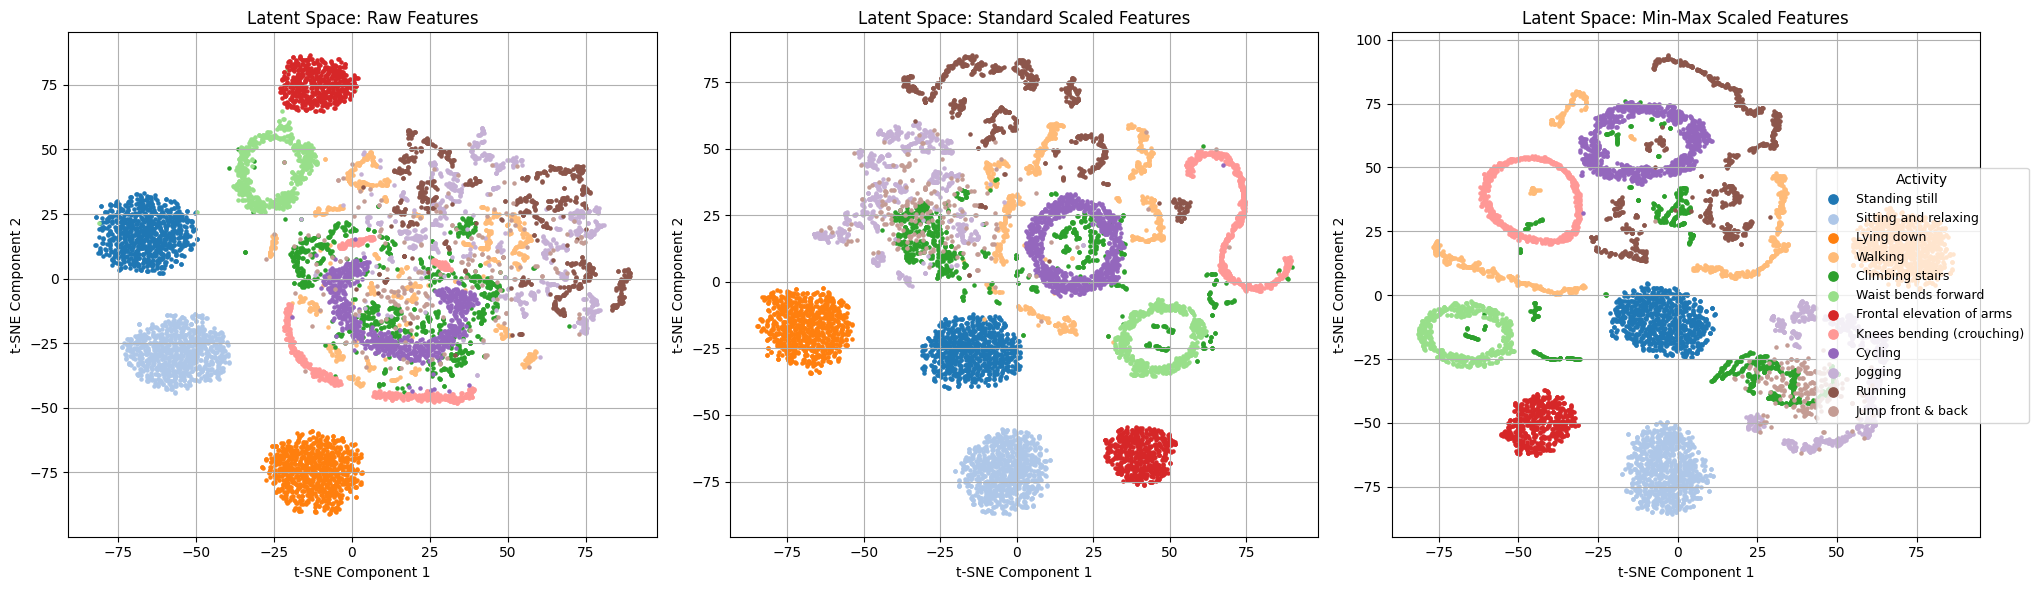

In [12]:
# Visualize latent representations with t-SNE
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, scale_type in enumerate(['raw', 'std', 'minmax']):
    X_test = datasets[scale_type]['X_test']
    y_test = datasets[scale_type]['y_test']

    # Extract latent features
    latent = encoders[scale_type].predict(X_test, verbose=0)
    latent_tsne = TSNE(n_components=2, perplexity=30, learning_rate=300, n_iter=1000, random_state=42).fit_transform(latent)

    # Plot
    unique_labels = sorted(np.unique(y_test))
    cmap = get_cmap('tab20')
    colors = {label: cmap(i % 20) for i, label in enumerate(unique_labels)}

    for label in unique_labels:
        label_idx = y_test == label
        axes[idx].scatter(latent_tsne[label_idx, 0], latent_tsne[label_idx, 1], s=5, color=colors[label], label=label_map[label])

    title_map = {'raw': 'Raw Features', 'std': 'Standard Scaled Features', 'minmax': 'Min-Max Scaled Features'}
    axes[idx].set_title(f"Latent Space: {title_map[scale_type]}")
    axes[idx].set_xlabel("t-SNE Component 1")
    axes[idx].set_ylabel("t-SNE Component 2")
    axes[idx].grid(True)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Activity", loc='center right', bbox_to_anchor=(1.02, 0.5), fontsize=9, markerscale=3)
plt.tight_layout()
plt.show()

## 🎯 Section 7: Training Base Classifiers

Train three classifiers (one per scaling approach) on latent features to map to 12-class predictions. Each learns different decision boundaries based on its input scaling.

In [13]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential

# === Extract latent features and labels (one-hot) ===
latent_data = {}

for scale_type in ['raw', 'std', 'minmax']:
    y_train = datasets[scale_type]['y_train']
    y_test = datasets[scale_type]['y_test']
    X_train = datasets[scale_type]['X_train']
    X_test = datasets[scale_type]['X_test']

    # Extract latent features
    latent_train = encoders[scale_type].predict(X_train, verbose=0)
    latent_test = encoders[scale_type].predict(X_test, verbose=0)

    # Convert labels to one-hot
    y_train_cat = to_categorical(y_train, num_classes=12)
    y_test_cat = to_categorical(y_test, num_classes=12)

    latent_data[scale_type] = {
        'latent_train': latent_train, 'latent_test': latent_test,
        'y_train_cat': y_train_cat, 'y_test_cat': y_test_cat,
        'y_test': y_test  # Keep original labels for evaluation
    }

# === Define and train classifiers ===
def build_classifier(input_dim, num_classes=12):
    model = Sequential([
        Dense(20, activation='relu', input_shape=(input_dim,)),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

classifiers = {}

for scale_type in ['raw', 'std', 'minmax']:
    print(f"\n{'='*50}")
    print(f"Training Classifier for {scale_type.upper()} features")
    print('='*50)

    latent_train = latent_data[scale_type]['latent_train']
    y_train_cat = latent_data[scale_type]['y_train_cat']

    clf = build_classifier(latent_train.shape[1])
    clf.fit(latent_train, y_train_cat, epochs=50, batch_size=256, verbose=1)

    classifiers[scale_type] = clf

print("\n✅ All classifiers trained successfully")


Training Classifier for RAW features
Epoch 1/50
84/84 [==============================] - 1s 3ms/step - loss: 3.9050 - accuracy: 0.2521
Epoch 2/50
84/84 [==============================] - 0s 3ms/step - loss: 2.0541 - accuracy: 0.3927
Epoch 3/50
84/84 [==============================] - 0s 3ms/step - loss: 1.7105 - accuracy: 0.4654
Epoch 4/50
84/84 [==============================] - 0s 5ms/step - loss: 1.4880 - accuracy: 0.5065
Epoch 5/50
84/84 [==============================] - 0s 4ms/step - loss: 1.3199 - accuracy: 0.5431
Epoch 6/50
84/84 [==============================] - 0s 4ms/step - loss: 1.1885 - accuracy: 0.5774
Epoch 7/50
84/84 [==============================] - 0s 5ms/step - loss: 1.0874 - accuracy: 0.6138
Epoch 8/50
84/84 [==============================] - 0s 4ms/step - loss: 1.0036 - accuracy: 0.6490
Epoch 9/50
84/84 [==============================] - 0s 4ms/step - loss: 0.9235 - accuracy: 0.6911
Epoch 10/50
84/84 [==============================] - 0s 4ms/step - loss: 0.8477 

## 📈 Section 8: Base Classifier Evaluation

Evaluate individual classifier performance with confusion matrices before passing to the meta-classifier.


Classification Report: Raw Features
                           precision    recall  f1-score   support

           Standing still       0.99      1.00      1.00       823
     Sitting and relaxing       1.00      1.00      1.00       823
               Lying down       1.00      1.00      1.00       823
                  Walking       0.85      0.89      0.87       823
          Climbing stairs       0.83      0.75      0.79       823
      Waist bends forward       0.99      0.95      0.97       562
Frontal elevation of arms       0.96      1.00      0.98       531
Knees bending (crouching)       0.98      0.89      0.93       593
                  Cycling       0.82      0.95      0.88       823
                  Jogging       0.90      0.76      0.83       823
                  Running       0.79      0.91      0.84       823
        Jump front & back       0.73      0.56      0.64       209

                 accuracy                           0.91      8479
                macro a

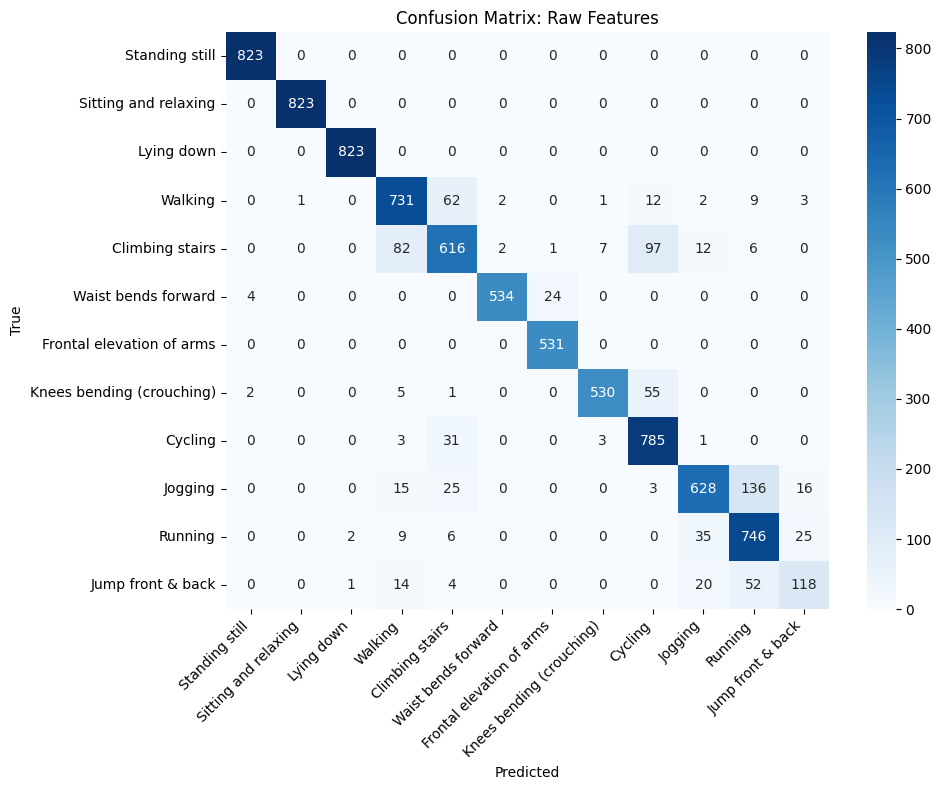


Classification Report: Standard Scaled Features
                           precision    recall  f1-score   support

           Standing still       1.00      1.00      1.00       823
     Sitting and relaxing       1.00      1.00      1.00       823
               Lying down       1.00      1.00      1.00       823
                  Walking       0.95      0.96      0.95       823
          Climbing stairs       0.90      0.82      0.86       823
      Waist bends forward       0.98      1.00      0.99       562
Frontal elevation of arms       1.00      1.00      1.00       531
Knees bending (crouching)       0.95      0.96      0.95       593
                  Cycling       0.91      0.97      0.94       823
                  Jogging       0.91      0.92      0.91       823
                  Running       0.97      0.98      0.97       823
        Jump front & back       0.72      0.60      0.66       209

                 accuracy                           0.95      8479
           

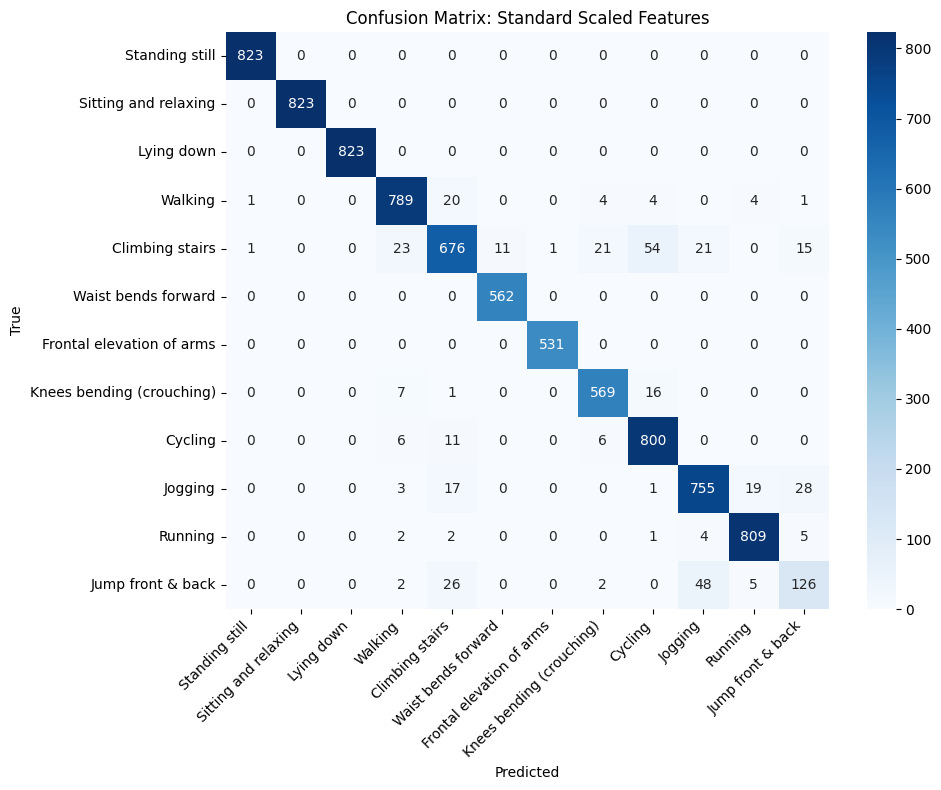


Classification Report: Min-Max Scaled Features
                           precision    recall  f1-score   support

           Standing still       0.98      1.00      0.99       823
     Sitting and relaxing       0.98      1.00      0.99       823
               Lying down       1.00      1.00      1.00       823
                  Walking       0.88      0.86      0.87       823
          Climbing stairs       0.74      0.52      0.61       823
      Waist bends forward       0.94      0.82      0.87       562
Frontal elevation of arms       0.82      1.00      0.90       531
Knees bending (crouching)       0.70      0.62      0.66       593
                  Cycling       0.69      0.89      0.77       823
                  Jogging       0.89      0.90      0.90       823
                  Running       0.97      0.86      0.91       823
        Jump front & back       0.48      0.73      0.58       209

                 accuracy                           0.86      8479
            

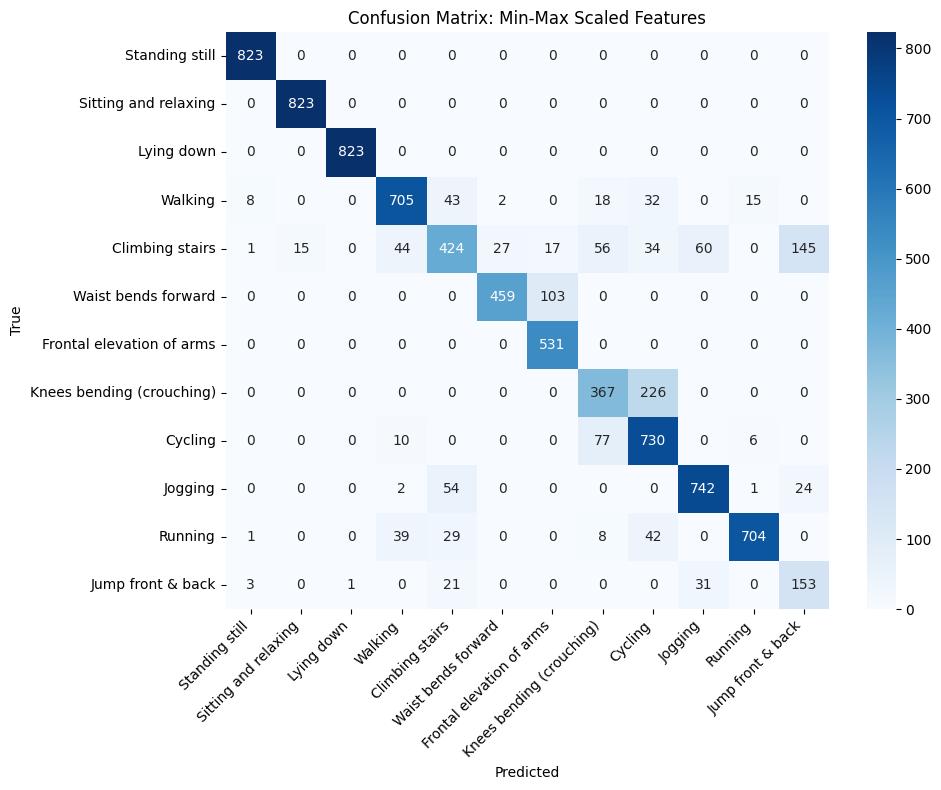

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_classifier(clf, latent_test, y_test_true, title):
    """Evaluate classifier and display classification report and confusion matrix."""
    # Predict class probabilities → class labels
    y_pred = np.argmax(clf.predict(latent_test, verbose=0), axis=1)

    # Classification report
    print(f"\n{'='*70}")
    print(f"Classification Report: {title}")
    print('='*70)
    print(classification_report(y_test_true, y_pred, target_names=[label_map[i] for i in sorted(label_map)]))

    # Confusion matrix
    cm = confusion_matrix(y_test_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[label_map[i] for i in sorted(label_map)],
                yticklabels=[label_map[i] for i in sorted(label_map)])
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Evaluate all classifiers
for scale_type in ['raw', 'std', 'minmax']:
    title_map = {'raw': 'Raw Features', 'std': 'Standard Scaled Features', 'minmax': 'Min-Max Scaled Features'}

    latent_test = latent_data[scale_type]['latent_test']
    y_test = latent_data[scale_type]['y_test']

    evaluate_classifier(classifiers[scale_type], latent_test, y_test, title_map[scale_type])

## 🎁 Section 9: Ensemble Combination - Stacking (Core Ensemble Technique)

**Stacking** combines diverse base classifiers using a meta-learner. Extract 12-dim softmax outputs from each of the 3 base classifiers and concatenate into a 36-dimensional vector. This becomes the input for the meta-classifier, which learns optimal feature combinations for final predictions.

In [15]:
# Get classifier outputs for stacking
train_logits = {}
test_logits = {}

for scale_type in ['raw', 'std', 'minmax']:
    latent_train = latent_data[scale_type]['latent_train']
    latent_test = latent_data[scale_type]['latent_test']

    train_logits[scale_type] = classifiers[scale_type].predict(latent_train, verbose=0)
    test_logits[scale_type] = classifiers[scale_type].predict(latent_test, verbose=0)

# Stack outputs horizontally to create 36-dim ensemble input (12 × 3 classifiers)
X_train_ensemble = np.hstack([train_logits['raw'], train_logits['std'], train_logits['minmax']])
X_test_ensemble = np.hstack([test_logits['raw'], test_logits['std'], test_logits['minmax']])

# Use raw labels as target (consistent across all scaling approaches)
y_train_ensemble_cat = latent_data['raw']['y_train_cat']
y_test_ensemble_cat = latent_data['raw']['y_test_cat']

print(f"\n✅ Ensemble data prepared:")
print(f"   X_train_ensemble shape: {X_train_ensemble.shape} (36-dim: 12×3 classifiers)")
print(f"   X_test_ensemble shape:  {X_test_ensemble.shape}")


✅ Ensemble data prepared:
   X_train_ensemble shape: (21350, 36) (36-dim: 12×3 classifiers)
   X_test_ensemble shape:  (8479, 36)


## 🔗 Section 10: Meta-Classifier Training (Core Ensemble Concept)

Train a meta-classifier that learns non-linear combinations of the 36-dim base predictions: Dense(24, relu) → Dense(12, softmax). This is where the ensemble learns its power—combining diverse base models optimally.

In [16]:
# Meta-classifier: single layer mapping 36 → 12
meta_clf = Sequential([
    Dense(24, activation='relu', input_shape=(36,)),
    Dense(12, activation='softmax')
])
meta_clf.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
meta_clf.fit(X_train_ensemble, y_train_ensemble_cat, epochs=50, batch_size=256, verbose=1)

Epoch 1/50
84/84 [==============================] - 1s 3ms/step - loss: 2.1661 - accuracy: 0.4163
Epoch 2/50
84/84 [==============================] - 0s 3ms/step - loss: 1.2599 - accuracy: 0.9296
Epoch 3/50
84/84 [==============================] - 0s 3ms/step - loss: 0.5186 - accuracy: 0.9744
Epoch 4/50
84/84 [==============================] - 0s 3ms/step - loss: 0.2203 - accuracy: 0.9852
Epoch 5/50
84/84 [==============================] - 0s 3ms/step - loss: 0.1213 - accuracy: 0.9889
Epoch 6/50
84/84 [==============================] - 0s 3ms/step - loss: 0.0814 - accuracy: 0.9904
Epoch 7/50
84/84 [==============================] - 0s 3ms/step - loss: 0.0616 - accuracy: 0.9909
Epoch 8/50
84/84 [==============================] - 0s 3ms/step - loss: 0.0503 - accuracy: 0.9916
Epoch 9/50
84/84 [==============================] - 0s 3ms/step - loss: 0.0434 - accuracy: 0.9917
Epoch 10/50
84/84 [==============================] - 0s 3ms/step - loss: 0.0387 - accuracy: 0.9918
Epoch 11/50
84/84 [


Classification Report: Stacked Ensemble (3 × Classifiers Output)
                           precision    recall  f1-score   support

           Standing still       1.00      1.00      1.00       823
     Sitting and relaxing       1.00      1.00      1.00       823
               Lying down       1.00      1.00      1.00       823
                  Walking       0.99      0.99      0.99       823
          Climbing stairs       0.98      0.95      0.96       823
      Waist bends forward       1.00      1.00      1.00       562
Frontal elevation of arms       1.00      1.00      1.00       531
Knees bending (crouching)       1.00      0.98      0.99       593
                  Cycling       0.96      1.00      0.98       823
                  Jogging       0.98      0.99      0.98       823
                  Running       1.00      1.00      1.00       823
        Jump front & back       0.91      0.91      0.91       209

                 accuracy                           0.99     

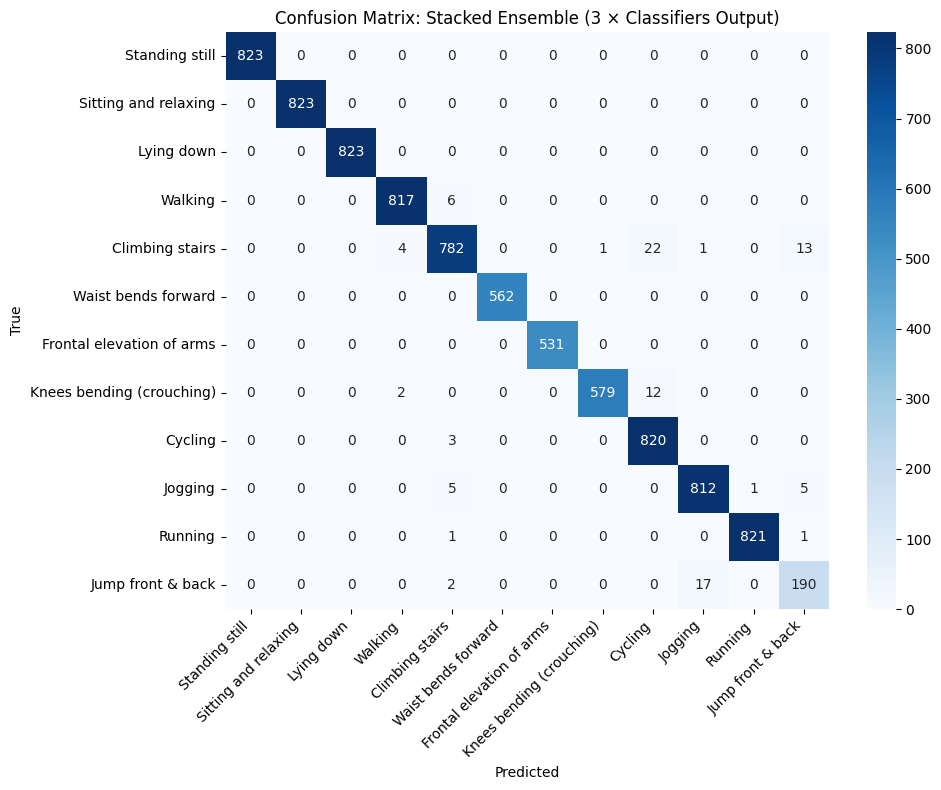

In [17]:
y_test_raw = latent_data['raw']['y_test']

evaluate_classifier(meta_clf, X_test_ensemble, y_test_raw, "Stacked Ensemble (3 × Classifiers Output)")


## 📦 Section 11: Model Conversion to TFLite

Convert trained Keras models to TensorFlow Lite format for optimization and deployment.

In [18]:
import tensorflow as tf
import os

def convert_and_save(model, name):
    # Convert to TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()

    # Save to file
    filename = f"{name}.tflite"
    with open(filename, "wb") as f:
        f.write(tflite_model)

    # Report size in KB
    size_kb = os.path.getsize(filename) / 1024
    print(f"{name}: {size_kb:.2f} KB")

# --- Convert and measure ---
convert_and_save(encoders['raw'], "encoder_raw")
convert_and_save(classifiers["raw"], "clf_raw")

convert_and_save(encoders['std'], "encoder_std")
convert_and_save(classifiers["std"], "clf_std")

convert_and_save(encoders['minmax'], "encoder_minmax")
convert_and_save(classifiers["minmax"], "clf_minmax")

convert_and_save(meta_clf, "stacked_meta_clf")

encoder_raw: 159.23 KB
clf_raw: 5.24 KB
encoder_std: 159.23 KB
clf_std: 5.26 KB
encoder_minmax: 159.25 KB
clf_minmax: 5.26 KB
stacked_meta_clf: 6.34 KB


## 🔄 Section 12: Model Flattening - End-to-End Pipelines

Merge encoders and classifiers into single end-to-end models for efficient deployment.

In [19]:
def flatten_encoder_classifier(encoder, classifier, name="flattened_model"):
    """Create a single end-to-end model by stacking encoder → classifier."""
    model = Sequential(name=name)
    for layer in encoder.layers:
        model.add(layer)
    for layer in classifier.layers:
        model.add(layer)
    return model

# Create flattened encoder+classifier models for each scaling approach
flattened_models = {}

for scale_type in ['raw', 'std', 'minmax']:
    flattened_models[scale_type] = flatten_encoder_classifier(
        encoders[scale_type],
        classifiers[scale_type],
        name=f"encoder_clf_{scale_type}_flat"
    )

print("✅ Flattened end-to-end models created for all three scaling approaches")

✅ Flattened end-to-end models created for all three scaling approaches


## ⚙️ Section 13: Pruning, Quantization-Aware Training (QAT), and Export

This is the core compression pipeline for deploying models on resource-constrained hardware. We apply two critical optimization techniques:

### 1. **Pruning**
- **Goal**: Remove less important weights (set to zero) to reduce model size
- **Method**: Polynomial decay schedule gradually increases sparsity from 10% to 80%
- **Benefit**: Smaller model, faster inference
- **Trade-off**: Slight accuracy loss, but usually acceptable

### 2. **Quantization-Aware Training (QAT)**
- **Goal**: Train with simulated INT8 quantization to adapt weights to 8-bit integers
- **Method**: After pruning, apply quantization wrappers and fine-tune
- **Benefit**: Extreme compression (4× reduction from FP32 to INT8)
- **Deployment**: Models run entirely on 8-bit arithmetic—perfect for Arduino

### Pipeline Steps

1. **Train and Prune**: Fine-tune model while gradually removing weights
2. **Extract Masks**: Store which weights were pruned (non-zero pattern)
3. **Quantize**: Apply QAT wrappers to simulate INT8 inference
4. **Enforce Masks**: Keep pruned weights at zero during QAT training
5. **Export to TFLite**: Generate compressed, quantized `.tflite` model
6. **Convert to C array**: Use `xxd` to generate C header for Arduino deployment

**Configuration**: 5 pruning epochs, 5 QAT epochs, 80% target sparsity, INT8 quantization.

In [20]:
import tensorflow as tf
import numpy as np
import os
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)
from tensorflow_model_optimization.quantization.keras import quantize_model, quantize_scope
from tensorflow_model_optimization.python.core.quantization.keras.quantize_wrapper import QuantizeWrapper
from sklearn.metrics import classification_report, confusion_matrix

# === CONFIG ===
batch_size = 256
prune_epochs = 5
qat_epochs = 5
end_step = 500
# ==============

# Step 1: Prune the model
def train_and_prune(model, X_train, y_train):
    prune_sched = PolynomialDecay(
        initial_sparsity=0.1,
        final_sparsity=0.8,
        begin_step=0,
        end_step=end_step
    )
    pruned_model = prune_low_magnitude(model, pruning_schedule=prune_sched)
    pruned_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    pruned_model.fit(X_train, y_train,
                     epochs=prune_epochs,
                     batch_size=batch_size,
                     callbacks=[UpdatePruningStep()],
                     verbose=1)
    return pruned_model

# Step 2: Extract pruning masks
def extract_pruned_weights_and_masks(model):
    pruned_weights_and_masks = []
    for layer in model.layers:
        weights = layer.get_weights()
        if weights:
            masks = [(w != 0).astype(np.float32) for w in weights]
            pruned_weights_and_masks.append((weights, masks, layer.name))
    return pruned_weights_and_masks

# Step 3: Callback to enforce masks during QAT
class MaskEnforcerCallback(tf.keras.callbacks.Callback):
    def __init__(self, masks):
        super().__init__()
        self.masks = masks

    def on_batch_end(self, batch, logs=None):
        for layer in self.model.layers:
            if isinstance(layer, QuantizeWrapper):
                weights = layer.get_weights()
                for pruned_weights, masks, original_name in self.masks:
                    if len(pruned_weights) < 2 or len(weights) < 2:
                        continue
                    if pruned_weights[0].shape == weights[0].shape and pruned_weights[1].shape == weights[1].shape:
                        masked_kernel = weights[0] * masks[0]
                        masked_bias = weights[1] * masks[1]
                        layer.set_weights([masked_kernel, masked_bias] + weights[2:])
                        break

# Step 4: Representative dataset generator
def make_representative_data_gen(X_subset):
    def generator():
        for i in range(len(X_subset)):
            yield [X_subset[i:i+1].astype(np.float32)]
    return generator

# Step 5: Evaluate TFLite model
def evaluate_tflite_model(tflite_model_path, X_test, y_test):
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    input_scale, input_zero_point = input_details[0]['quantization']
    correct = 0
    y_pred = []

    for i in range(len(X_test)):
        input_data = X_test[i:i+1].astype("float32")
        input_data = np.round(input_data / input_scale + input_zero_point).astype(np.int8)
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])
        pred = np.argmax(output_data)
        y_pred.append(pred)
        if pred == y_test[i]:
            correct += 1

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=1))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return correct / len(X_test)

# Step 6: Compute model sparsity
def compute_model_sparsity(model):
    total_weights = 0
    total_zeros = 0
    print("\n🔍 Layer-wise sparsity:")
    for layer in model.layers:
        if isinstance(layer, QuantizeWrapper):
            weights = layer.get_weights()
            if len(weights) >= 1:
                kernel = weights[0]
                zeros = np.sum(kernel == 0)
                size = np.prod(kernel.shape)
                total_weights += size
                total_zeros += zeros
                sparsity = 100.0 * zeros / size
                print(f" - {layer.name:25s}: {sparsity:5.2f}% sparse ({zeros}/{size})")
    total_sparsity = 100.0 * total_zeros / total_weights if total_weights > 0 else 0
    print(f"✅ Overall model sparsity: {total_sparsity:5.2f}% ({total_zeros}/{total_weights})")
    return total_sparsity

# Step 7: Full pipeline
def prune_qat_export(model, X_train, y_train, X_test, y_test, name):
    print(f"\n🔧 Pipeline for: {name}")

    # Step 1: Prune
    pruned_model = train_and_prune(model, X_train, y_train)

    print("\n🔍 Pruned model layer weights:")
    for i, layer in enumerate(pruned_model.layers):
        w = layer.get_weights()
        print(f"[{i}] {layer.name:25s} | #weights: {len(w)} | {[w_.shape for w_ in w]}")

    # Step 2: Extract pruning masks
    pruned_weights_and_masks = extract_pruned_weights_and_masks(pruned_model)

    # Step 3: QAT
    stripped_model = strip_pruning(pruned_model)
    with quantize_scope():
        qat_model = quantize_model(stripped_model)

    qat_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("⚙️  Training QAT model (with pruning mask callback)...")
    qat_model.fit(X_train, y_train,
                  epochs=qat_epochs,
                  batch_size=batch_size,
                  callbacks=[MaskEnforcerCallback(pruned_weights_and_masks)],
                  verbose=1)

    # Build model
    qat_model.predict(X_train[:1], verbose=0)

    print("\n🔍 QAT model wrapped layer weights:")
    for i, layer in enumerate(qat_model.layers):
        if isinstance(layer, QuantizeWrapper):
            w = layer.get_weights()
            print(f"[{i}] {layer.name:25s} | #weights: {len(w)} | {[w_.shape for w_ in w]}")

    # Final mask reapplication
    print("🧹 Reapplying pruning masks directly on QuantizeWrapper layers...")
    matched_layers = 0
    for layer in qat_model.layers:
        if isinstance(layer, QuantizeWrapper):
            weights = layer.get_weights()
            for pruned_weights, masks, original_name in pruned_weights_and_masks:
                if len(pruned_weights) < 2 or len(weights) < 2:
                    continue
                if pruned_weights[0].shape == weights[0].shape and pruned_weights[1].shape == weights[1].shape:
                    masked_kernel = weights[0] * masks[0]
                    masked_bias = weights[1] * masks[1]
                    new_weights = [masked_kernel, masked_bias] + weights[2:]
                    layer.set_weights(new_weights)
                    print(f"✅ Mask reapplied to QAT layer: {layer.name} (matched {original_name})")
                    matched_layers += 1
                    break
    print(f"🔍 Total QAT layers masked: {matched_layers}")

    # Step 4: Report model sparsity
    compute_model_sparsity(qat_model)

    # Step 5: Export to TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = make_representative_data_gen(X_train)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model = converter.convert()

    fname = f"{name}_pruned_qat_int8.tflite"
    with open(fname, "wb") as f:
        f.write(tflite_model)
    print(f"💾 Saved: {fname} ({os.path.getsize(fname)/1024:.2f} KB)")

    # Step 6: Evaluate final TFLite model
    acc = evaluate_tflite_model(fname, X_test, np.argmax(y_test, axis=1))
    print(f"✅ Final TFLite Accuracy: {acc:.4f}")


In [22]:
# Run compression pipeline for all three encoder+classifier models
for scale_type in ['raw', 'std', 'minmax']:
    X_train = datasets[scale_type]['X_train']
    X_test = datasets[scale_type]['X_test']
    y_train_cat = latent_data[scale_type]['y_train_cat']
    y_test_cat = latent_data[scale_type]['y_test_cat']

    prune_qat_export(
        flattened_models[scale_type],
        X_train, y_train_cat,
        X_test, y_test_cat,
        f"encoder_clf_{scale_type}"
    )


🔧 Pipeline for: encoder_clf_raw
Epoch 1/5
84/84 [==============================] - 3s 6ms/step - loss: 0.2179 - accuracy: 0.9337
Epoch 2/5
84/84 [==============================] - 0s 6ms/step - loss: 0.3482 - accuracy: 0.9115
Epoch 3/5
84/84 [==============================] - 0s 6ms/step - loss: 1.0625 - accuracy: 0.7770
Epoch 4/5
84/84 [==============================] - 0s 6ms/step - loss: 1.5944 - accuracy: 0.6121
Epoch 5/5
84/84 [==============================] - 0s 6ms/step - loss: 1.7799 - accuracy: 0.4415

🔍 Pruned model layer weights:
[0] prune_low_magnitude_dense | #weights: 2 | [(600, 64), (64,)]
[1] prune_low_magnitude_dense_1 | #weights: 2 | [(64, 32), (32,)]
[2] prune_low_magnitude_dense_18 | #weights: 2 | [(32, 20), (20,)]
[3] prune_low_magnitude_dense_19 | #weights: 2 | [(20, 12), (12,)]
⚙️  Training QAT model (with pruning mask callback)...
Epoch 1/5
 5/84 [>.............................] - ETA: 3s - loss: 2.1478 - accuracy: 0.2188

84/84 [==============================] - 5s 29ms/step - loss: 1.8718 - accuracy: 0.2440
Epoch 2/5
84/84 [==============================] - 2s 28ms/step - loss: 1.6516 - accuracy: 0.2602
Epoch 3/5
84/84 [==============================] - 2s 28ms/step - loss: 1.5386 - accuracy: 0.2618
Epoch 4/5
84/84 [==============================] - 2s 28ms/step - loss: 1.4632 - accuracy: 0.3156
Epoch 5/5
84/84 [==============================] - 3s 33ms/step - loss: 1.4042 - accuracy: 0.3544

🔍 QAT model wrapped layer weights:
[1] quant_dense               | #weights: 7 | [(600, 64), (64,), (), (), (), (), ()]
[2] quant_dense_1             | #weights: 7 | [(64, 32), (32,), (), (), (), (), ()]
[3] quant_dense_18            | #weights: 7 | [(32, 20), (20,), (), (), (), (), ()]
[4] quant_dense_19            | #weights: 7 | [(20, 12), (12,), (), (), (), (), ()]
🧹 Reapplying pruning masks directly on QuantizeWrapper layers...
✅ Mask reapplied to QAT layer: quant_dense (matched prune_low_magnitude_dense)
✅ M

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


💾 Saved: encoder_clf_raw_pruned_qat_int8.tflite (44.23 KB)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       823
           1       1.00      0.00      0.00       823
           2       1.00      0.00      0.00       823
           3       1.00      0.00      0.00       823
           4       0.13      0.96      0.22       823
           5       1.00      0.00      0.00       562
           6       1.00      0.00      0.00       531
           7       0.99      1.00      0.99       593
           8       0.96      0.97      0.97       823
           9       1.00      0.00      0.00       823
          10       1.00      0.00      0.00       823
          11       1.00      0.00      0.00       209

    accuracy                           0.35      8479
   macro avg       0.92      0.33      0.27      8479
weighted avg       0.91      0.35      0.28      8479

Confusion Matrix:
[[823   0   0   0   0   0   0   

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


...

84/84 [==============================] - 4s 34ms/step - loss: 0.9828 - accuracy: 0.5711
Epoch 2/5
84/84 [==============================] - 2s 27ms/step - loss: 0.7972 - accuracy: 0.7455
Epoch 3/5
84/84 [==============================] - 2s 28ms/step - loss: 0.6992 - accuracy: 0.8170
Epoch 4/5
84/84 [==============================] - 2s 27ms/step - loss: 0.6313 - accuracy: 0.8949
Epoch 5/5
84/84 [==============================] - 2s 27ms/step - loss: 0.5854 - accuracy: 0.9265



🔍 QAT model wrapped layer weights:
[1] quant_dense_12            | #weights: 7 | [(600, 64), (64,), (), (), (), (), ()]
[2] quant_dense_13            | #weights: 7 | [(64, 32), (32,), (), (), (), (), ()]
[3] quant_dense_22            | #weights: 7 | [(32, 20), (20,), (), (), (), (), ()]
[4] quant_dense_23            | #weights: 7 | [(20, 12), (12,), (), (), (), (), ()]
🧹 Reapplying pruning masks directly on QuantizeWrapper layers...
✅ Mask reapplied to QAT layer: quant_dense_12 (matched prune_low_magnitude_dense_12)
✅ Mask reapplied to QAT layer: quant_dense_13 (matched prune_low_magnitude_dense_13)
✅ Mask reapplied to QAT layer: quant_dense_22 (matched prune_low_magnitude_dense_22)
✅ Mask reapplied to QAT layer: quant_dense_23 (matched prune_low_magnitude_dense_23)
🔍 Total QAT layers masked: 4

🔍 Layer-wise sparsity:
 - quant_dense_12           : 79.44% sparse (30505/38400)
 - quant_dense_13           : 79.44% sparse (1627/2048)
 - quant_dense_22           : 79.38% sparse (508/640)
 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


💾 Saved: encoder_clf_minmax_pruned_qat_int8.tflite (44.30 KB)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       823
           1       1.00      1.00      1.00       823
           2       1.00      1.00      1.00       823
           3       0.92      1.00      0.96       823
           4       0.51      0.71      0.59       823
           5       1.00      0.86      0.92       562
           6       0.91      1.00      0.95       531
           7       0.60      0.24      0.34       593
           8       0.94      0.78      0.85       823
           9       0.99      0.99      0.99       823
          10       1.00      1.00      1.00       823
          11       0.60      0.89      0.71       209

    accuracy                           0.88      8479
   macro avg       0.87      0.87      0.86      8479
weighted avg       0.89      0.88      0.88      8479

Confusion Matrix:
[[823   0   0   0   0   0   0

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [21]:
prune_qat_export(
    meta_clf,
    X_train_ensemble, y_train_ensemble_cat,
    X_test_ensemble, y_test_ensemble_cat,
    "stacked_meta_clf"
)


🔧 Pipeline for: stacked_meta_clf
Epoch 1/5
84/84 [==============================] - 6s 4ms/step - loss: 0.0204 - accuracy: 0.9935
Epoch 2/5
84/84 [==============================] - 4s 46ms/step - loss: 0.0306 - accuracy: 0.9926
Epoch 3/5
84/84 [==============================] - 0s 4ms/step - loss: 0.1427 - accuracy: 0.9805
Epoch 4/5
84/84 [==============================] - 0s 4ms/step - loss: 0.2931 - accuracy: 0.8921
Epoch 5/5
84/84 [==============================] - 0s 4ms/step - loss: 0.3387 - accuracy: 0.9454

🔍 Pruned model layer weights:
[0] prune_low_magnitude_dense_24 | #weights: 2 | [(36, 24), (24,)]
[1] prune_low_magnitude_dense_25 | #weights: 2 | [(24, 12), (12,)]
⚙️  Training QAT model (with pruning mask callback)...
Epoch 1/5
 4/84 [>.............................] - ETA: 1s - loss: 0.4090 - accuracy: 0.8770  

84/84 [==============================] - 2s 16ms/step - loss: 0.3367 - accuracy: 0.9551
Epoch 2/5
84/84 [==============================] - 2s 19ms/step - loss: 0.2422 - accuracy: 0.9833
Epoch 3/5
84/84 [==============================] - 2s 21ms/step - loss: 0.1888 - accuracy: 0.9863
Epoch 4/5
84/84 [==============================] - 1s 15ms/step - loss: 0.1533 - accuracy: 0.9876
Epoch 5/5
84/84 [==============================] - 1s 16ms/step - loss: 0.1276 - accuracy: 0.9882

🔍 QAT model wrapped layer weights:
[1] quant_dense_24            | #weights: 7 | [(36, 24), (24,), (), (), (), (), ()]
[2] quant_dense_25            | #weights: 7 | [(24, 12), (12,), (), (), (), (), ()]
🧹 Reapplying pruning masks directly on QuantizeWrapper layers...
✅ Mask reapplied to QAT layer: quant_dense_24 (matched prune_low_magnitude_dense_24)
✅ Mask reapplied to QAT layer: quant_dense_25 (matched prune_low_magnitude_dense_25)
🔍 Total QAT layers masked: 2

🔍 Layer-wise sparsity:
 - quant_dense_24           

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


💾 Saved: stacked_meta_clf_pruned_qat_int8.tflite (3.41 KB)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       823
           1       1.00      1.00      1.00       823
           2       1.00      1.00      1.00       823
           3       0.97      1.00      0.98       823
           4       0.97      0.93      0.95       823
           5       1.00      1.00      1.00       562
           6       0.99      1.00      1.00       531
           7       1.00      0.97      0.98       593
           8       0.96      0.99      0.97       823
           9       0.95      0.98      0.97       823
          10       1.00      1.00      1.00       823
          11       0.95      0.79      0.86       209

    accuracy                           0.98      8479
   macro avg       0.98      0.97      0.98      8479
weighted avg       0.98      0.98      0.98      8479

Confusion Matrix:
[[823   0   0   0   0   0   0   

## 📊 Section 14: Model Size Analysis

Report compressed model sizes after pruning and quantization.

In [23]:
import os

def get_model_size_kb(path):
    size_bytes = os.path.getsize(path)
    return size_bytes / 1024  # KB

model_names = [
    "encoder_clf_raw_pruned_qat_int8.tflite",
    "encoder_clf_std_pruned_qat_int8.tflite",
    "encoder_clf_minmax_pruned_qat_int8.tflite",
    "stacked_meta_clf_pruned_qat_int8.tflite"
]

print("\n--- Quantized TFLite Model Sizes ---")
print("{:<35} {:>10}".format("Model", "Size (KB)"))
print("-" * 48)

for name in model_names:
    if os.path.exists(name):
        size_kb = get_model_size_kb(name)
        print("{:<35} {:>10.2f}".format(name, size_kb))
    else:
        print("{:<35} {:>10}".format(name, "Not found"))



--- Quantized TFLite Model Sizes ---
Model                                Size (KB)
------------------------------------------------
encoder_clf_raw_pruned_qat_int8.tflite      44.23
encoder_clf_std_pruned_qat_int8.tflite      44.25
encoder_clf_minmax_pruned_qat_int8.tflite      44.30
stacked_meta_clf_pruned_qat_int8.tflite       3.41


## 💻 Section 15: Convert Models to C Code

Convert TFLite models to C arrays for Arduino deployment.

In [24]:
!xxd -i encoder_clf_raw_pruned_qat_int8.tflite       > encoder_clf_raw_pruned_qat_int8.cc
!xxd -i encoder_clf_std_pruned_qat_int8.tflite       > encoder_clf_std_pruned_qat_int8.cc
!xxd -i encoder_clf_minmax_pruned_qat_int8.tflite    > encoder_clf_minmax_pruned_qat_int8.cc
!xxd -i stacked_meta_clf_pruned_qat_int8.tflite      > stacked_meta_clf_pruned_qat_int8.cc


## 🔢 Section 16: Scaling Parameters

Extract and display training scaling parameters for Arduino preprocessing.

In [25]:
import pandas as pd

# Assume you already have sensor_df with 6 features
# Columns: ['Accel_X', 'Accel_Y', 'Accel_Z', 'Gyro_X', 'Gyro_Y', 'Gyro_Z']

print("\n--- Standard Scaling Parameters (mean and std) ---")
means = sensor_df.mean()
stds = sensor_df.std()
for col in sensor_df.columns:
    print(f"{col}: mean = {means[col]:.6f}, std = {stds[col]:.6f}")

print("\n--- MinMax Scaling Parameters (min and max) ---")
mins = sensor_df.min()
maxs = sensor_df.max()
for col in sensor_df.columns:
    print(f"{col}: min = {mins[col]:.6f}, max = {maxs[col]:.6f}")



--- Standard Scaling Parameters (mean and std) ---
Accel_X: mean = 3.268805, std = 4.253270
Accel_Y: mean = -9.153526, std = 5.397648
Accel_Z: mean = 0.700608, std = 6.433731
Gyro_X: mean = -0.020571, std = 0.325434
Gyro_Y: mean = -0.520382, std = 0.571107
Gyro_Z: mean = -0.299817, std = 0.542112
Label: mean = 5.112871, std = 3.391086

--- MinMax Scaling Parameters (min and max) ---
Accel_X: min = -22.091000, max = 20.003000
Accel_Y: min = -19.571000, max = 20.909000
Accel_Z: min = -19.363000, max = 24.599000
Gyro_X: min = -0.977740, max = 1.463800
Gyro_Y: min = -1.611600, max = 1.557200
Gyro_Z: min = -1.206300, max = 1.326100
Label: min = 0.000000, max = 11.000000


## 📥 Section 17: Testing with Real Recorded IMU Data

Validate models on new unseen IMU data collected via `Raw_IMU_Recorder.ino` (minimum 500 rows).

In [27]:
import pandas as pd
import numpy as np

# Load and rename
df_new = pd.read_csv("imu_500_rows.csv")
df_new.rename(columns={
    'acc_x': 'Accel_X', 'acc_y': 'Accel_Y', 'acc_z': 'Accel_Z',
    'gyro_x': 'Gyro_X', 'gyro_y': 'Gyro_Y', 'gyro_z': 'Gyro_Z'
}, inplace=True)
# Remove the timestamp column
del df_new["timestamp_ms"]

# Standardization parameters
standard_means = {
    'Accel_X': 3.268805, 'Accel_Y': -9.153526, 'Accel_Z': 0.700608,
    'Gyro_X': -0.020571, 'Gyro_Y': -0.520382, 'Gyro_Z': -0.299817
}
standard_stds = {
    'Accel_X': 4.253270, 'Accel_Y': 5.397648, 'Accel_Z': 6.433731,
    'Gyro_X': 0.325434, 'Gyro_Y': 0.571107, 'Gyro_Z': 0.542112
}

# MinMax parameters
min_vals = {
    'Accel_X': -22.091, 'Accel_Y': -19.571, 'Accel_Z': -19.363,
    'Gyro_X': -0.97774, 'Gyro_Y': -1.6116, 'Gyro_Z': -1.2063
}
max_vals = {
    'Accel_X': 20.003, 'Accel_Y': 20.909, 'Accel_Z': 24.599,
    'Gyro_X': 1.4638, 'Gyro_Y': 1.5572, 'Gyro_Z': 1.3261
}

# Scale
df_std = df_new.copy()
df_minmax = df_new.copy()
for col in df_new.columns:
    df_std[col] = (df_new[col] - standard_means[col]) / standard_stds[col]
    df_minmax[col] = (df_new[col] - min_vals[col]) / (max_vals[col] - min_vals[col])

# Windowing
WINDOW_SIZE = 100
STRIDE = 1
def create_windows(df):
    X = df.values
    return np.array([X[i:i+WINDOW_SIZE].flatten() for i in range(0, len(X) - WINDOW_SIZE + 1, STRIDE)])

# Final inputs
X_raw_new = create_windows(df_new)
X_std_new = create_windows(df_std)
X_minmax_new = create_windows(df_minmax)

print("✅ New input windows created:")
print(" - X_raw_new shape:     ", X_raw_new.shape)
print(" - X_std_new shape:     ", X_std_new.shape)
print(" - X_minmax_new shape:  ", X_minmax_new.shape)



✅ New input windows created:
 - X_raw_new shape:      (5897, 600)
 - X_std_new shape:      (5897, 600)
 - X_minmax_new shape:   (5897, 600)


## 🎨 Section 18: Ensemble Inference on New Data

Run all three base models and the meta-classifier on new IMU data to evaluate ensemble performance.

In [30]:
import numpy as np

# Initialize the inferences dictionary
inferences = {}

# Store predicted outputs from individual classifiers
base_classifier_predictions_new = {}

for scale_type, X_new_data in zip(['raw', 'std', 'minmax'], [X_raw_new, X_std_new, X_minmax_new]):
    # Get latent features from the encoder
    latent_features_new = encoders[scale_type].predict(X_new_data, verbose=0)

    # Get softmax probabilities from the classifier
    classifier_outputs_new = classifiers[scale_type].predict(latent_features_new, verbose=0)

    # Store predicted class labels for direct evaluation
    inferences[scale_type] = {'predictions': np.argmax(classifier_outputs_new, axis=1)}

    # Store softmax outputs for the meta-classifier
    base_classifier_predictions_new[scale_type] = classifier_outputs_new

# Prepare input for the meta-classifier
X_ensemble_new = np.hstack([
    base_classifier_predictions_new['raw'],
    base_classifier_predictions_new['std'],
    base_classifier_predictions_new['minmax']
])

# Get predictions from the meta-classifier
meta_clf_outputs_new = meta_clf.predict(X_ensemble_new, verbose=0)
inferences['meta'] = {'predictions': np.argmax(meta_clf_outputs_new, axis=1)}

# Alternative: Display activity label names for the first 10 predictions
print("\n🎯 Predicted Activity Labels (first 10 windows):\n")
for scale_type in ['raw', 'std', 'minmax']:
    preds = inferences[scale_type]['predictions'][:10]
    activities = [label_map[p] for p in preds]
    print(f"{scale_type.upper():8s}: {activities[:3]}...")  # Show first 3 for brevity
print(f"{'META':8s}: {[label_map[p] for p in inferences['meta']['predictions'][:10][:3]]}...")

# Summary statistics
print("\n📊 Prediction Statistics on New Data:\n")
for scale_type in ['raw', 'std', 'minmax', 'meta']:
    preds = inferences[scale_type]['predictions']
    unique, counts = np.unique(preds, return_counts=True)
    print(f"{scale_type.upper():8s}: Most common activity is '{label_map[unique[np.argmax(counts)]]}' "
          f"({counts.max()}/{len(preds)} windows)")


🎯 Predicted Activity Labels (first 10 windows):

RAW     : ['Climbing stairs', 'Climbing stairs', 'Climbing stairs']...
STD     : ['Lying down', 'Lying down', 'Lying down']...
MINMAX  : ['Jump front & back', 'Lying down', 'Lying down']...
META    : ['Jogging', 'Walking', 'Climbing stairs']...

📊 Prediction Statistics on New Data:

RAW     : Most common activity is 'Climbing stairs' (5672/5897 windows)
STD     : Most common activity is 'Climbing stairs' (1941/5897 windows)
MINMAX  : Most common activity is 'Running' (1677/5897 windows)
META    : Most common activity is 'Climbing stairs' (3251/5897 windows)
